## **Semibatch Reactor Balance**

### **Principle of operation of a semibatch reactor**
For both chemical and biological engineering, semibatch (semiflow) reactors operate much like batch reactors in that they take place in a single stirred tank with similar equipment. However, they are modified to allow reactant addition and/or product removal in time.

A normal batch reactor is filled with reactants in a single stirred tank at time t=0 and the reaction proceeds. A semibatch reactor, however, allows partial filling of reactants with the flexibility of adding more as time progresses. Stirring in both types is very efficient, which allows batch and semibatch reactors to assume a uniform composition and temperature throughout.

![https://www.filsonfilters.com/wp-content/uploads/2020/11/Figure-4-Semi-batch-reactor.png](https://www.filsonfilters.com/wp-content/uploads/2020/11/Figure-4-Semi-batch-reactor.png)

> Source: https://www.filsonfilters.com/chemical-reactors

> Source: https://en.wikipedia.org/wiki/Semibatch_reactor

### **Material and energy balance**

The general axiom of material balancing says that:

$\begin{bmatrix} \text{Component} \\ \text{accumulation} \end{bmatrix} = \begin{bmatrix} \text{Component} \\ \text{inlet} \end{bmatrix} - \begin{bmatrix} \text{Component} \\ \text{outlet} \end{bmatrix} + \begin{bmatrix} \text{Component} \\ \text{production} \end{bmatrix} - \begin{bmatrix} \text{Component} \\ \text{consumption} \end{bmatrix}$

The general axiom of energy balancing says that:

$\begin{bmatrix} \text{Energy} \\ \text{accumulation} \end{bmatrix} = \begin{bmatrix} \text{Energy} \\ \text{inlet} \end{bmatrix} - \begin{bmatrix} \text{Energy} \\ \text{outlet} \end{bmatrix} + \begin{bmatrix} \text{Effect of} \\ \text{chemical reaction} \end{bmatrix}$

$\text{}$

For the $[\text{A}] + [\text{B}] \rightarrow [\text{...}]$ type reaction carried out in a semibatch reactor with substance A dosing, the above balancing scheme will be simplified and will take the form:

$\begin{bmatrix} \text{Component A} \\ \text{accumulation} \end{bmatrix} = \begin{bmatrix} \text{Component A} \\ \text{inlet} \end{bmatrix} - \underbrace{\begin{bmatrix} \text{Component A} \\ \text{outlet} \end{bmatrix}}_{0} + \underbrace{\begin{bmatrix} \text{Component A} \\ \text{production} \end{bmatrix}}_{0} - \begin{bmatrix} \text{Component A} \\ \text{consumption} \end{bmatrix}$

The balance equation for component A becomes:

$\frac{d(Vc_{A})}{dt} = Qc_{A, in} - {kc}_{A}c_{B}V$

$V\frac{dc_{A}}{dt} + c_{A}\frac{dV}{dt} = Qc_{A, in} - kc_{A}c_{B}V$

$V\frac{dc_{A}}{dt} + c_{A}Q = Qc_{A, in} - kc_{A}c_{B}V$

$V\frac{dc_{A}}{dt} = Q(c_{A, in} - c_{A}) - kc_{A}c_{B}V$

$\frac{dc_{A}}{dt} = \frac{Q}{V}(c_{A,in} - c_{A}) - kc_{A}c_{B}$

Analogous transformations can be performed for component B:

$\begin{bmatrix} \text{Component B} \\ \text{accumulation} \end{bmatrix} = \underbrace{\begin{bmatrix} \text{Component B} \\ \text{inlet} \end{bmatrix}}_{0} - \underbrace{\begin{bmatrix} \text{Component B} \\ \text{outlet} \end{bmatrix}}_{0} + \underbrace{\begin{bmatrix} \text{Component B} \\ \text{production} \end{bmatrix}}_{0} - \begin{bmatrix} \text{Component B} \\ \text{consumption} \end{bmatrix}$

$\frac{dc_{B}}{dt} = -\frac{Q}{V}c_{B} - kc_{A}c_{B}$

For the $[\text{A}] + [\text{B}] \rightarrow [\text{...}]$ type reaction analysed above (without cooling), the energy balance will be as follows:

$\begin{bmatrix} \text{Energy} \\ \text{accumulation} \end{bmatrix} = \begin{bmatrix} \text{Energy} \\ \text{inlet} \end{bmatrix} - \underbrace{\begin{bmatrix} \text{Energy} \\ \text{outlet} \end{bmatrix}}_{0} + \begin{bmatrix} \text{Effect of} \\ \text{chemical reaction} \end{bmatrix}$

$\rho C_{p}\frac{d(VT)}{dt} = Q \rho C_{p} T_{in} + {kc}_{A}c_{B}(- \Delta H)V$

$\rho C_{p} V\frac{dT}{dt} + \rho C_{p} T \frac{dV}{dt} = Q \rho C_{p} T_{in} + {kc}_{A}c_{B}(- \Delta H)V$

$\rho C_{p} V\frac{dT}{dt} + \rho C_{p} T Q = Q \rho C_{p} T_{in}  + {kc}_{A}c_{B}(- \Delta H)V$

$V\frac{dT}{dt} = Q \rho C_{p} (T_{in} - T) + \frac{{kc}_{A}c_{B}(- \Delta H)V}{\rho C_{p}}$

$\frac{dT}{dt} = \frac{Q}{V} \rho C_{p} (T_{in} - T) + \frac{{kc}_{A}c_{B}(- \Delta H)}{\rho C_{p}}$

> Source: https://www.ichip.pw.edu.pl/content/download/6853/30405/file/IRCh1_3_Reaktory%20idealne.pdf

## **Here we go!**

We will carry out calculations to plot the graphical dependence of the concentration of substances A and B in the reaction medium for two separate variants.
* Variant #1: Reaction of $[\text{A}] + [\text{B}] \rightarrow [\text{...}]$ in a semi-batch reactor, maintaining a constant temperature of the reaction medium, dosing substance A over a period of time.
* Variant #2: Reaction of $[\text{A}] + [\text{B}] \rightarrow [\text{...}]$ in a semi-batch reactor, without cooling, influenced by an exo-energetic reaction, dosing substance A over a period of time.

In [1]:
# Import the necessary modules and functions
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from scipy.integrate import solve_ivp

---
### **Constants declaration**
Constant values that are used in numerical calculations are declared below.

In [2]:
# Initial concentration of substances A and B in the reactor
global cAin;    cAin = 16.000
global cBin;    cBin = 6.000

# Dosing time for substance A
global tA;      tA = 13.5

# Reaction environment temperature and Arrhenius equation constants
global K;       K = 2.25E+06
global E;       E = 48000
global T;       T = 285.15
global R;       R = 8.3145

# Volume of solutions A and B that is involved in the reaction
global VA;      VA = 1.5
global VB;      VB = 4.0

# Enthalpy of reaction, average specific heat of reaction fluid and its density
global dH;      dH = -170
global Cp;      Cp = 4.19
global rho;     rho = 1.10

# Dosing temperature of substance A solution
global Tin;     Tin = 385.15

---
### **Function declaration**
The functions that will be used in the numerical calculations of the concentration of individual components in the reaction medium are presented below.

In [3]:
# Constant speed of reaction
def k(T):
    k = K * np.exp(-E/(R*T))
    return k

In [4]:
# Volume rate of substance A that is fed to the reactor
def Q(t):
    if t <= tA:
        Q = VA/tA
    else:
        Q = 0
    return Q

In [5]:
# Volume of fluid in the reactor
def V(t):
    V = VB + Q(t) * t
    return V

---
### **Systems of balance equations and their numerical solution**
The *solve_ivp* function of the *scipy* module can be used to solve a system of ordinary differential equations.

#### **Variant #1**

Reaction of $[\text{A}] + [\text{B}] \rightarrow [\text{...}]$ in a semi-batch reactor, maintaining a constant temperature of the reaction medium, dosing substance A over a period of time.

In [6]:
# Simulation duration and declaration of initial conditions
t_start    = 0         
t_end      = 200
t_steps    = 2000

time_span = np.array([t_start, t_end])
time_point = np.linspace(t_start, t_end, t_steps)
start_variant_1 = np.array([0, cBin])

In [7]:
# Equations describing the concentration of substances A and B
def variant_1(t, y):
    dydt = np.zeros(np.size(y))
    
    # dydt[0] = dcA/dt   y[0] = cA
    # dydt[1] = dcB/dt   y[1] = cB
    
    dydt[0] =  Q(t)/V(t) * (cAin - y[0]) - k(T) * y[0] * y[1]
    dydt[1] = -Q(t)/V(t) * y[1] - k(T) * y[0] * y[1]
        
    return dydt

In [8]:
# Calculating the system of differential equations
result_variant_1 = solve_ivp(variant_1, time_span, start_variant_1, method = 'LSODA')
result_variant_1['success']

True

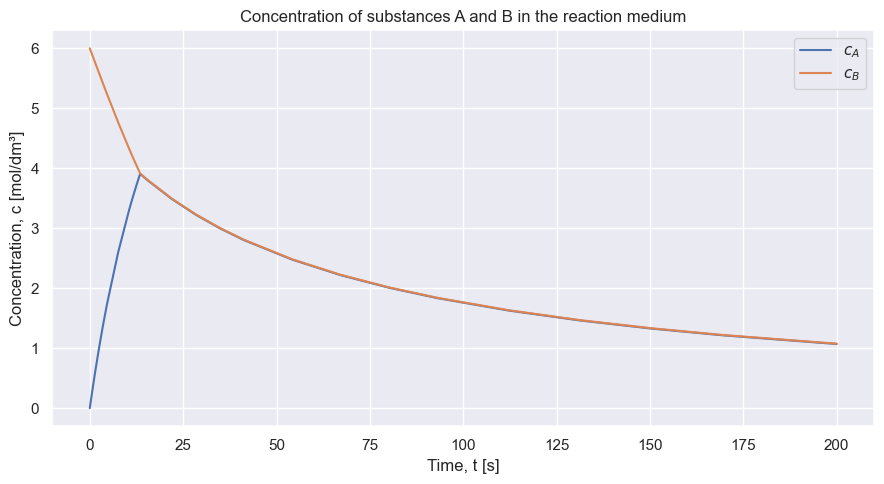

In [9]:
# Results - concentration vs. time graph
plt.figure(figsize = (9, 5))

plt.plot(result_variant_1.t, result_variant_1.y[0,:], result_variant_1.t, result_variant_1.y[1,:])
plt.title('Concentration of substances A and B in the reaction medium')
plt.legend(['$c_{A}$','$c_{B}$'])
plt.xlabel('Time, t [s]')
plt.ylabel('Concentration, c [mol/dm³]')
plt.tight_layout()
plt.show()

#### **Variant #2**

Reaction of $[\text{A}] + [\text{B}] \rightarrow [\text{...}]$ in a semi-batch reactor, without cooling, influenced by an exo-energetic reaction, dosing substance A over a period of time.

In [10]:
# Simulation duration and declaration of initial conditions
t_start    = 0         
t_end      = 30
t_steps    = 1000

time_span = np.array([t_start, t_end])
time_point = np.linspace(t_start, t_end, t_steps)
start_variant_2 = np.array([0, cBin, T])

In [11]:
# Equations describing the concentration of substances A and B and the temperature of the reaction medium
def variant_2(t, y):
    dydt = np.zeros(np.size(y))
    
    # dydt[0] = dcA/dt   y[0] = cA
    # dydt[1] = dcB/dt   y[1] = cB
    # dydt[2] = dT/dt    y[2] = T
    
    dydt[0] =  Q(t)/V(t) * (cAin - y[0]) - k(y[2]) * y[0] * y[1]
    dydt[1] = -Q(t)/V(t) * y[1] - k(y[2]) * y[0] * y[1]
    dydt[2] =  Q(t)/V(t) * (Tin - y[2]) + k(y[2]) * y[0] * y[1] * (-dH) * (rho * Cp)**(-1)
        
    return dydt

In [12]:
# Calculating the system of differential equations
result_variant_2 = solve_ivp(variant_2, time_span, start_variant_2, method = 'LSODA')
result_variant_2['success']

True

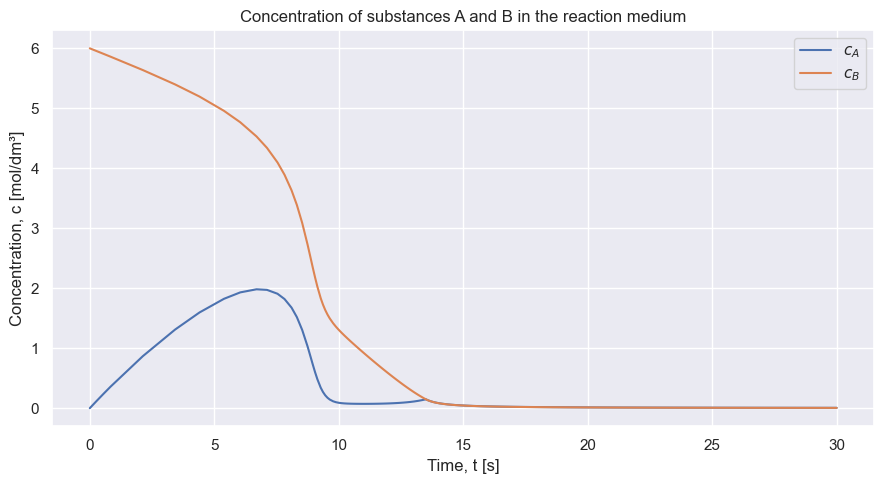

In [13]:
# Results - concentration vs. time graph
plt.figure(figsize = (9, 5))

plt.plot(result_variant_2.t, result_variant_2.y[0,:], result_variant_2.t, result_variant_2.y[1,:])
plt.title('Concentration of substances A and B in the reaction medium')
plt.legend(['$c_{A}$','$c_{B}$'])
plt.xlabel('Time, t [s]')
plt.ylabel('Concentration, c [mol/dm³]')
plt.tight_layout()
plt.show()

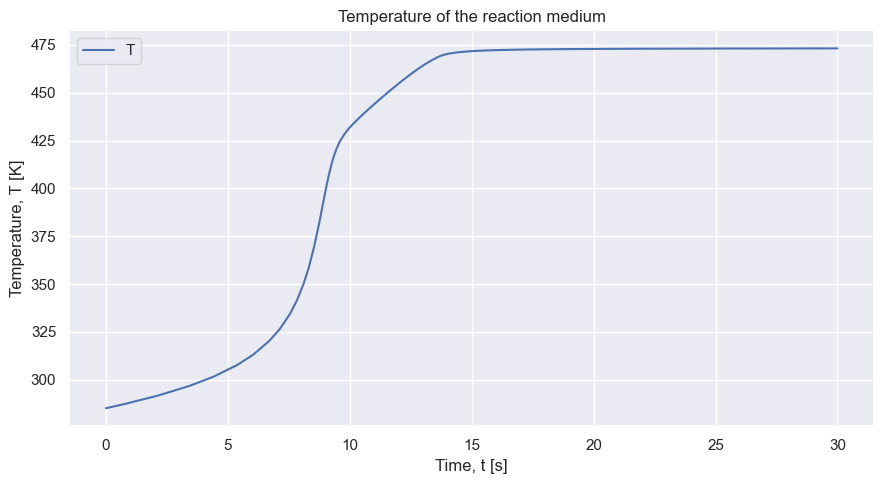

In [14]:
# Results - temperature vs. time graph
plt.figure(figsize = (9, 5))

plt.plot(result_variant_2.t, result_variant_2.y[2, :])
plt.title('Temperature of the reaction medium')
plt.legend(['T'])
plt.xlabel('Time, t [s]')
plt.ylabel('Temperature, T [K]')
plt.tight_layout()
plt.show()